# SVM-Only Comparison at Markov Blankets

This notebook compares methods using only **SVM** rows from each `mb_cardinality_metrics_summary.csv`.

It reports:
- Average inefficiency and certainty per method.
- Stratified plots by sample size (`250`, `1000`, `5000`).
- Ranking tables (average ranks).
- Critical difference diagrams for paper-ready statistical reporting.

Saving paths are kept in code but save commands are commented out to avoid automatic writes.


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import friedmanchisquare

try:
    from scipy.stats import studentized_range
except Exception:
    studentized_range = None

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')


In [2]:
# Paths (kept for reproducibility)
RESULTS_ROOT = Path('/mnt/storage/mlopezdecas/MRMR/new_experiments/RESULTS/synthetic')
OUTPUT_DIR = RESULTS_ROOT / 'mb_cardinality_method_comparison'
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_SIZES = [250, 1000, 5000]
PLOT_METHOD_EXCLUDE = {'JMI-MS', 'Smfs-linear'}

FOLDER_PATTERN = re.compile(r'^(?P<network>.+?)__target_(?P<target>.+?)__n_(?P<n_samples>\d+)__rep_(?P<rep>\d+)$')

METHOD_ALIAS = {
    'MS': 'Smfs',
    'MS_linear': 'Smfs-linear',
    'mRMR': 'mRMR',
    'MRMR': 'mRMR',
    'mRMR_MS_linear': 'mRMR-MS',
    'relax_mRMR': 'Relax-mRMR',
    'JMI': 'JMI',
    'JMI_MS_linear': 'JMI-MS',
}

RESULTS_ROOT


PosixPath('/mnt/storage/mlopezdecas/MRMR/new_experiments/RESULTS/synthetic')

In [3]:
def collect_mb_cardinality_metrics(results_root: Path) -> pd.DataFrame:
    rows = []
    for save_dir in sorted(results_root.glob('save_*')):
        if not save_dir.is_dir():
            continue

        dataset_name = save_dir.name.replace('save_', '')
        for run_dir in sorted(save_dir.iterdir()):
            if not run_dir.is_dir():
                continue

            m = FOLDER_PATTERN.match(run_dir.name)
            if not m:
                continue

            csv_path = run_dir / 'results' / 'mb_cardinality_metrics_summary.csv'
            if not csv_path.exists():
                continue

            df = pd.read_csv(csv_path)
            if df.empty:
                continue

            df = df.copy()
            df['dataset_name'] = dataset_name
            df['network_name'] = m.group('network')
            df['target_name'] = m.group('target')
            df['n_samples'] = int(m.group('n_samples'))
            df['replication_id'] = int(m.group('rep'))
            rows.append(df)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out['method'] = out['method_output_name'].map(METHOD_ALIAS).fillna(out['method_output_name'])

    for col in ['mb_size', 'mean_inefficiency', 'mean_certainty', 'n_samples']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')

    return out


In [4]:
raw_df = collect_mb_cardinality_metrics(RESULTS_ROOT)
if raw_df.empty:
    raise ValueError('No mb_cardinality_metrics_summary.csv data found.')

svm_df = raw_df[raw_df['classifier'].astype(str).str.upper() == 'SVM'].copy()
if svm_df.empty:
    raise ValueError('No SVM rows found in the loaded metrics files.')

print(f'Rows loaded (all classifiers): {len(raw_df):,}')
print(f'Rows kept (SVM only): {len(svm_df):,}')
print('Methods in SVM data:', sorted(svm_df['method'].dropna().unique().tolist()))
print('Sample sizes in SVM data:', sorted(svm_df['n_samples'].dropna().unique().astype(int).tolist()))

# One observation per experiment-method (SVM only)
obs_df = (
    svm_df
    .dropna(subset=['method', 'mean_inefficiency', 'mean_certainty'])
    .groupby(
        ['dataset_name', 'network_name', 'target_name', 'n_samples', 'replication_id', 'mb_size', 'method'],
        as_index=False
    )[['mean_inefficiency', 'mean_certainty']]
    .mean()
)

print(f'Observation rows (experiment-method, SVM): {len(obs_df):,}')
plot_df = obs_df.loc[~obs_df['method'].isin(PLOT_METHOD_EXCLUDE)].copy()
print('Methods used in plots/rankings:', sorted(plot_df['method'].dropna().unique().tolist()))
obs_df.head()


Rows loaded (all classifiers): 3,532
Rows kept (SVM only): 1,766
Methods in SVM data: ['JMI', 'JMI-MS', 'Relax-mRMR', 'Smfs', 'Smfs-linear', 'mRMR', 'mRMR-MS']
Sample sizes in SVM data: [250, 1000, 5000]
Observation rows (experiment-method, SVM): 1,766
Methods used in plots/rankings: ['JMI', 'Relax-mRMR', 'Smfs', 'mRMR', 'mRMR-MS']


,dataset_name,network_name,target_name,n_samples,replication_id,mb_size,method,mean_inefficiency,mean_certainty
0,arth150,arth150,108,250,1,6,JMI,8.2517,0.0000
1,arth150,arth150,108,250,1,6,JMI-MS,8.7059,0.0000
2,arth150,arth150,108,250,1,6,Relax-mRMR,8.1957,0.0000
3,arth150,arth150,108,250,1,6,Smfs,9.1933,0.0000
4,arth150,arth150,108,250,1,6,Smfs-linear,9.1933,0.0000


In [5]:
summary_method = (
    plot_df.groupby('method', as_index=False)
    .agg(
        n_obs=('mean_inefficiency', 'size'),
        avg_inefficiency=('mean_inefficiency', 'mean'),
        std_inefficiency=('mean_inefficiency', 'std'),
        avg_certainty=('mean_certainty', 'mean'),
        std_certainty=('mean_certainty', 'std'),
    )
    .sort_values('avg_inefficiency', ascending=True)
    .reset_index(drop=True)
)

# summary_method.to_csv(OUTPUT_DIR / "summary_by_method_svm.csv", index=False)
summary_method


,method,n_obs,avg_inefficiency,std_inefficiency,avg_certainty,std_certainty
0,mRMR,251,6.7727,2.3975,0.0547,0.1869
1,JMI,251,6.7784,2.3540,0.0581,0.1847
2,Relax-mRMR,251,6.8098,2.3452,0.0563,0.1875
3,Smfs,251,6.8416,2.3686,0.0524,0.1848
4,mRMR-MS,251,6.8449,2.3682,0.0520,0.1834


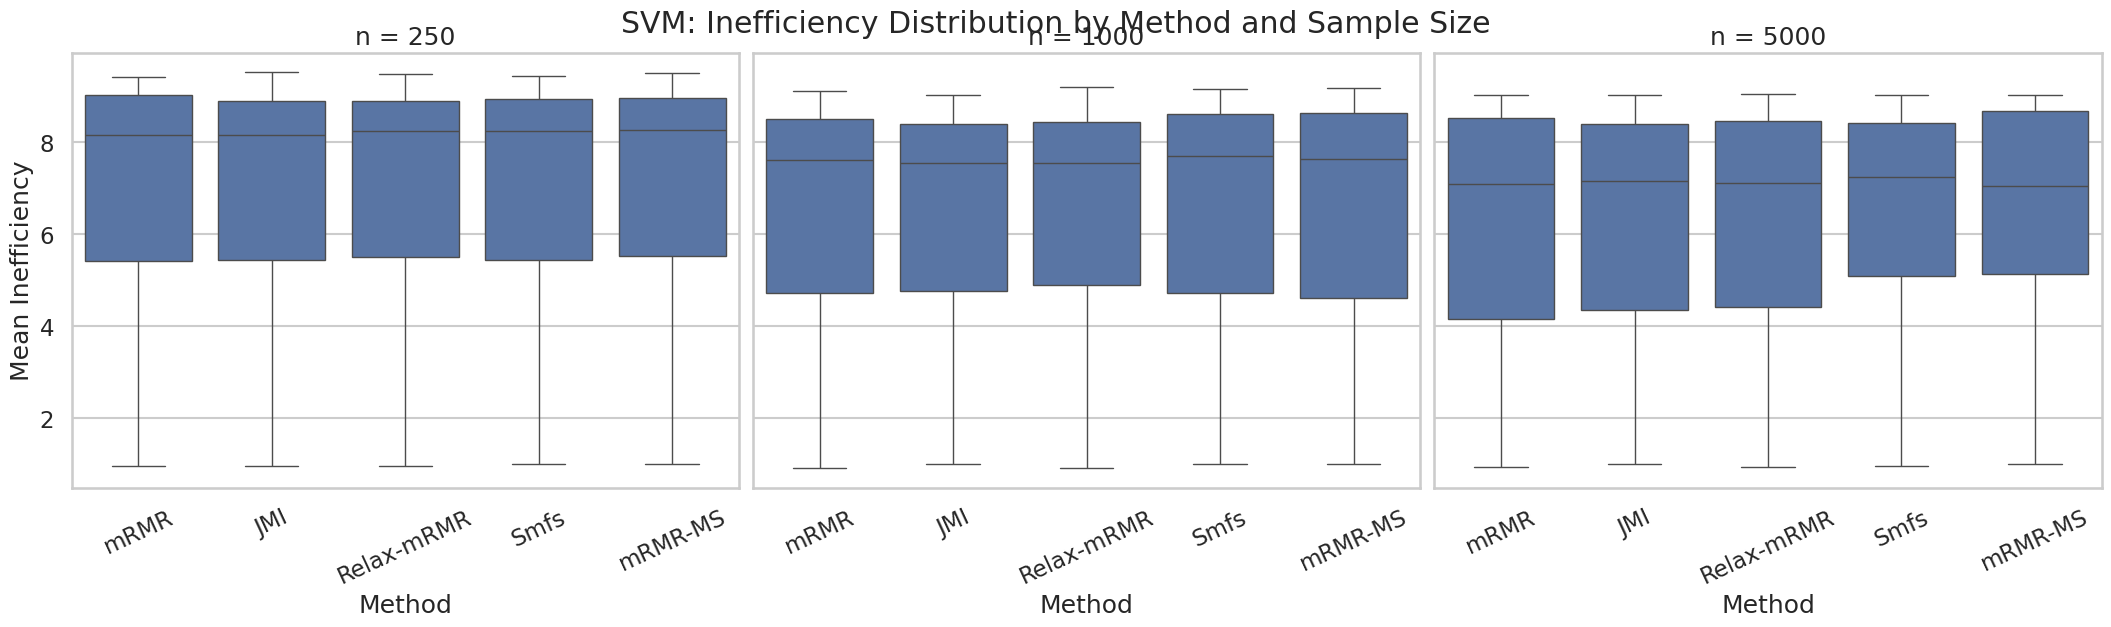

In [6]:
# Stratified inefficiency plots by n_samples
method_order = summary_method['method'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True, constrained_layout=True)

for i, n in enumerate(SAMPLE_SIZES):
    sub = plot_df[plot_df['n_samples'] == n]
    ax = axes[i]
    if sub.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'n = {n}')
        ax.set_xticks([])
        continue

    sns.boxplot(data=sub, x='method', y='mean_inefficiency', order=method_order, showfliers=False, ax=ax)
    ax.set_title(f'n = {n}')
    ax.set_xlabel('Method')
    ax.set_ylabel('Mean Inefficiency' if i == 0 else '')
    ax.tick_params(axis='x', rotation=25)

fig.suptitle('SVM: Inefficiency Distribution by Method and Sample Size', y=1.02)
# fig.savefig(OUTPUT_DIR / "svm_inefficiency_boxplot_by_samples.png", dpi=220, bbox_inches="tight")
plt.show()


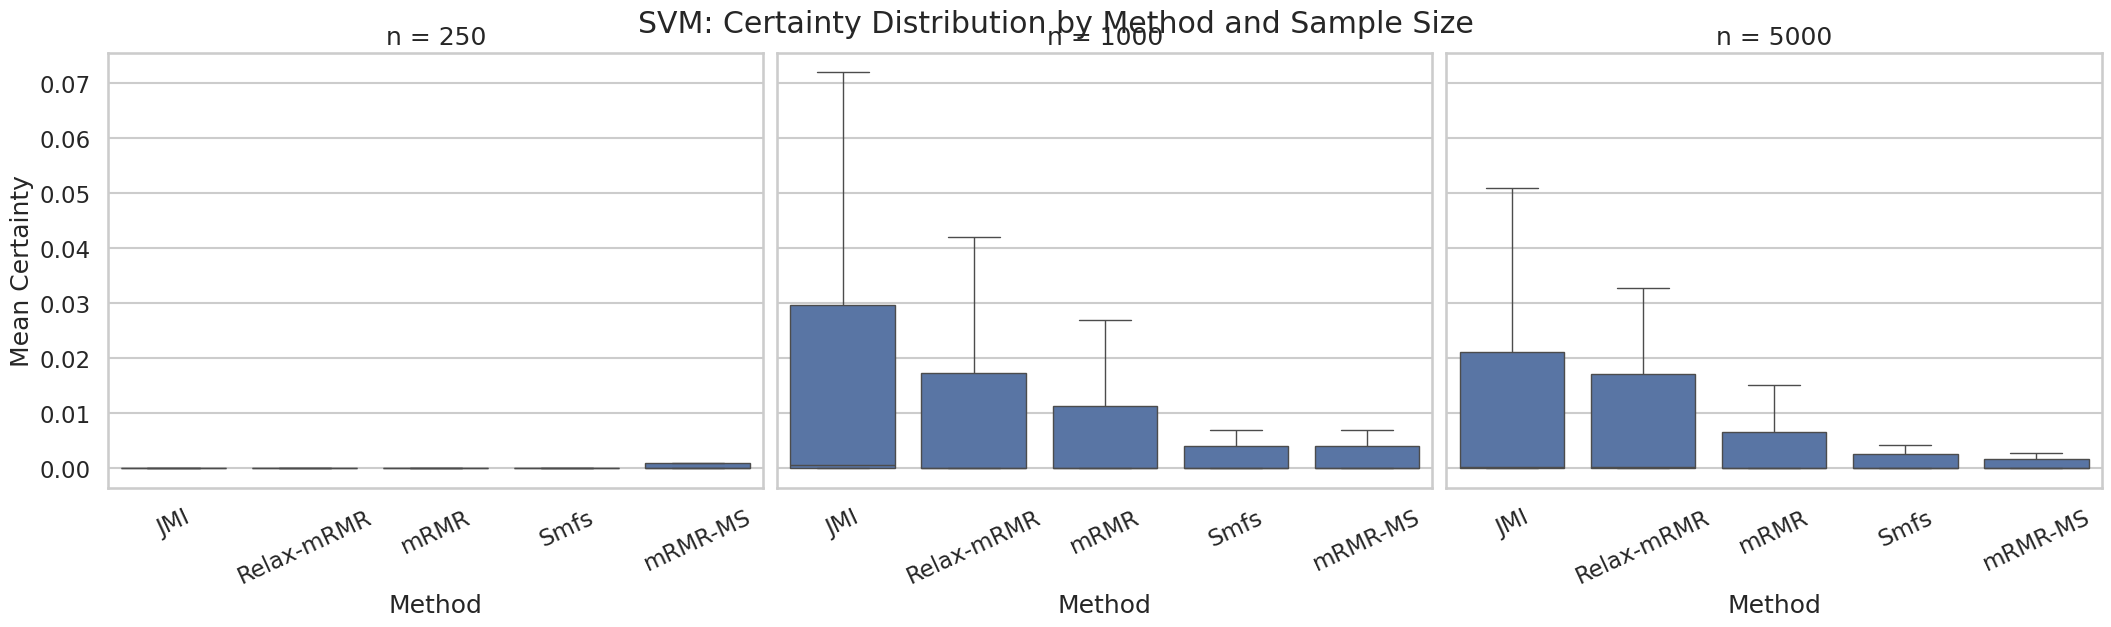

In [7]:
# Stratified certainty plots by n_samples
method_order_cert = summary_method.sort_values('avg_certainty', ascending=False)['method'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True, constrained_layout=True)

for i, n in enumerate(SAMPLE_SIZES):
    sub = plot_df[plot_df['n_samples'] == n]
    ax = axes[i]
    if sub.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'n = {n}')
        ax.set_xticks([])
        continue

    sns.boxplot(data=sub, x='method', y='mean_certainty', order=method_order_cert, showfliers=False, ax=ax)
    ax.set_title(f'n = {n}')
    ax.set_xlabel('Method')
    ax.set_ylabel('Mean Certainty' if i == 0 else '')
    ax.tick_params(axis='x', rotation=25)

fig.suptitle('SVM: Certainty Distribution by Method and Sample Size', y=1.02)
# fig.savefig(OUTPUT_DIR / "svm_certainty_boxplot_by_samples.png", dpi=220, bbox_inches="tight")
plt.show()


In [8]:
def _build_complete_matrix(data: pd.DataFrame, metric: str, sample_size: int | None = None, min_coverage: float = 0.90):
    sub = data.copy()
    if sample_size is not None:
        sub = sub[sub['n_samples'] == sample_size].copy()

    id_cols = [
        'dataset_name', 'network_name', 'target_name', 'n_samples', 'replication_id',
    ]
    long_df = (
        sub.groupby(id_cols + ['method'], as_index=False)[metric]
        .mean()
    )

    pivot = long_df.pivot_table(index=id_cols, columns='method', values=metric, aggfunc='mean')
    coverage = pivot.notna().mean().sort_values(ascending=False)

    methods = coverage[coverage >= min_coverage].index.tolist()
    if len(methods) < 2:
        methods = coverage.index.tolist()

    matrix = pivot[methods].dropna()
    return matrix, coverage


def _critical_distance(k: int, n: int, alpha: float = 0.05) -> float:
    if k < 2 or n < 2:
        return np.nan

    if studentized_range is not None:
        q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2.0)
    else:
        q_table_005 = {2: 1.960, 3: 2.344, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164}
        if k not in q_table_005:
            return np.nan
        q_alpha = q_table_005[k]

    return float(q_alpha * np.sqrt(k * (k + 1) / (6.0 * n)))


def compute_rank_results(data: pd.DataFrame, metric: str, ascending: bool):
    specs = [('overall', None), ('n=250', 250), ('n=1000', 1000), ('n=5000', 5000)]
    rows = []
    matrices = {}
    rank_means = {}

    for label, sample_size in specs:
        matrix, coverage = _build_complete_matrix(data, metric=metric, sample_size=sample_size, min_coverage=0.90)
        matrices[label] = matrix

        if matrix.empty or matrix.shape[1] < 2:
            continue

        # Paired ranks are computed within each complete experimental unit
        # (dataset, network, target, n_samples, replication_id), then averaged.
        rank_df = matrix.rank(axis=1, ascending=ascending, method='average')
        avg_ranks = rank_df.mean(axis=0).sort_values()
        rank_means[label] = avg_ranks

        if matrix.shape[0] >= 2:
            stat, p_value = friedmanchisquare(*[matrix[col].values for col in matrix.columns])
        else:
            stat, p_value = np.nan, np.nan

        cd = _critical_distance(k=matrix.shape[1], n=matrix.shape[0], alpha=0.05)

        for method, rank_value in avg_ranks.items():
            rows.append({
                'subset': label,
                'metric': metric,
                'method': method,
                'avg_rank': rank_value,
                'N_datasets': matrix.shape[0],
                'k_methods': matrix.shape[1],
                'friedman_stat': stat,
                'friedman_p': p_value,
                'critical_distance_0.05': cd,
            })

    rank_long = pd.DataFrame(rows)
    if rank_long.empty:
        return rank_long, pd.DataFrame(), matrices, rank_means

    rank_table = rank_long.pivot_table(index='method', columns='subset', values='avg_rank')
    return rank_long, rank_table, matrices, rank_means


def plot_cd_diagram(avg_ranks: pd.Series, cd: float, title: str, ax: plt.Axes):
    avg_ranks = avg_ranks.sort_values()
    methods = avg_ranks.index.tolist()
    ranks = avg_ranks.values
    k = len(methods)

    ax.hlines(0.0, 1, k, color='black', linewidth=1.2)
    for tick in range(1, k + 1):
        ax.vlines(tick, -0.02, 0.02, color='black', linewidth=1.0)

    for i, (method, rank_value) in enumerate(zip(methods, ranks)):
        y_text = -0.12 - 0.08 * (i % 2)
        ax.plot([rank_value, rank_value], [0.0, y_text + 0.02], color='black', linewidth=1.0)
        ax.scatter([rank_value], [0.0], color='#1f77b4', s=28, zorder=3)
        ax.text(rank_value, y_text, method, rotation=35, ha='right', va='top', fontsize=9)

    if np.isfinite(cd):
        start = max(1.0, k - cd - 0.1)
        end = start + cd
        y_cd = 0.30
        ax.hlines(y_cd, start, end, color='black', linewidth=2.2)
        ax.vlines([start, end], y_cd - 0.02, y_cd + 0.02, color='black', linewidth=2.0)
        ax.text((start + end) / 2, y_cd + 0.03, f'CD={cd:.3f}', ha='center', va='bottom', fontsize=9)

        # Simple non-significant cliques (contiguous segments where rank distance <= CD)
        segments = []
        for i in range(k):
            max_j = i
            for j in range(i + 1, k):
                if ranks[j] - ranks[i] <= cd:
                    max_j = j
            if max_j > i:
                segments.append((i, max_j))

        filtered = []
        for s in segments:
            if any((s[0] >= t[0] and s[1] <= t[1] and s != t) for t in segments):
                continue
            filtered.append(s)

        for level, (i, j) in enumerate(filtered):
            y = 0.10 + 0.06 * level
            ax.hlines(y, ranks[i], ranks[j], color='black', linewidth=2.6)

    ax.set_xlim(0.8, k + 0.2)
    ax.set_ylim(-0.38, 0.42)
    ax.set_xticks(range(1, k + 1))
    ax.set_xlabel('Average rank (1 = best)')
    ax.set_yticks([])
    ax.set_title(title, fontsize=12)
    for spine in ['left', 'right', 'top']:
        ax.spines[spine].set_visible(False)


In [9]:
# Rank table for inefficiency (lower = better)
rank_long_ineff, rank_table_ineff, matrices_ineff, rank_means_ineff = compute_rank_results(
    plot_df, metric='mean_inefficiency', ascending=True
)

print("Inefficiency ranking metadata:")
print(rank_long_ineff[['subset','N_datasets','k_methods','friedman_stat','friedman_p','critical_distance_0.05']].drop_duplicates().sort_values('subset').to_string(index=False))
rank_table_ineff

# rank_table_ineff.to_csv(OUTPUT_DIR / "svm_rank_table_inefficiency.csv")


Inefficiency ranking metadata:
 subset  N_datasets  k_methods  friedman_stat  friedman_p  critical_distance_0.05
 n=1000          84          5         2.3769      0.6668                  0.6655
  n=250          84          5         2.7892      0.5937                  0.6655
 n=5000          83          5         3.7881      0.4354                  0.6695
overall         251          5         6.0130      0.1982                  0.3850


subset,n=1000,n=250,n=5000,overall
method,,,,
JMI,2.8155,2.8333,2.7530,2.8008
Relax-mRMR,3.0536,3.0476,3.1747,3.0916
Smfs,3.1488,3.2024,2.9277,3.0936
mRMR,3.0536,2.9107,3.0422,3.0020
mRMR-MS,2.9286,3.0060,3.1024,3.0120


In [10]:
# Rank table for certainty (higher = better => descending rank)
rank_long_cert, rank_table_cert, matrices_cert, rank_means_cert = compute_rank_results(
    plot_df, metric='mean_certainty', ascending=False
)

print("Certainty ranking metadata:")
print(rank_long_cert[['subset','N_datasets','k_methods','friedman_stat','friedman_p','critical_distance_0.05']].drop_duplicates().sort_values('subset').to_string(index=False))
rank_table_cert

# rank_table_cert.to_csv(OUTPUT_DIR / "svm_rank_table_certainty.csv")


Certainty ranking metadata:
 subset  N_datasets  k_methods  friedman_stat  friedman_p  critical_distance_0.05
 n=1000          84          5        16.2846      0.0027                  0.6655
  n=250          84          5         1.0745      0.8983                  0.6655
 n=5000          83          5         8.5272      0.0741                  0.6695
overall         251          5        17.9051      0.0013                  0.3850


subset,n=1000,n=250,n=5000,overall
method,,,,
JMI,2.6905,2.9940,2.8494,2.8446
Relax-mRMR,2.9226,3.0595,2.8072,2.9303
Smfs,3.3036,3.0238,3.1988,3.1753
mRMR,2.9286,2.9643,2.9940,2.9622
mRMR-MS,3.1548,2.9583,3.1506,3.0876


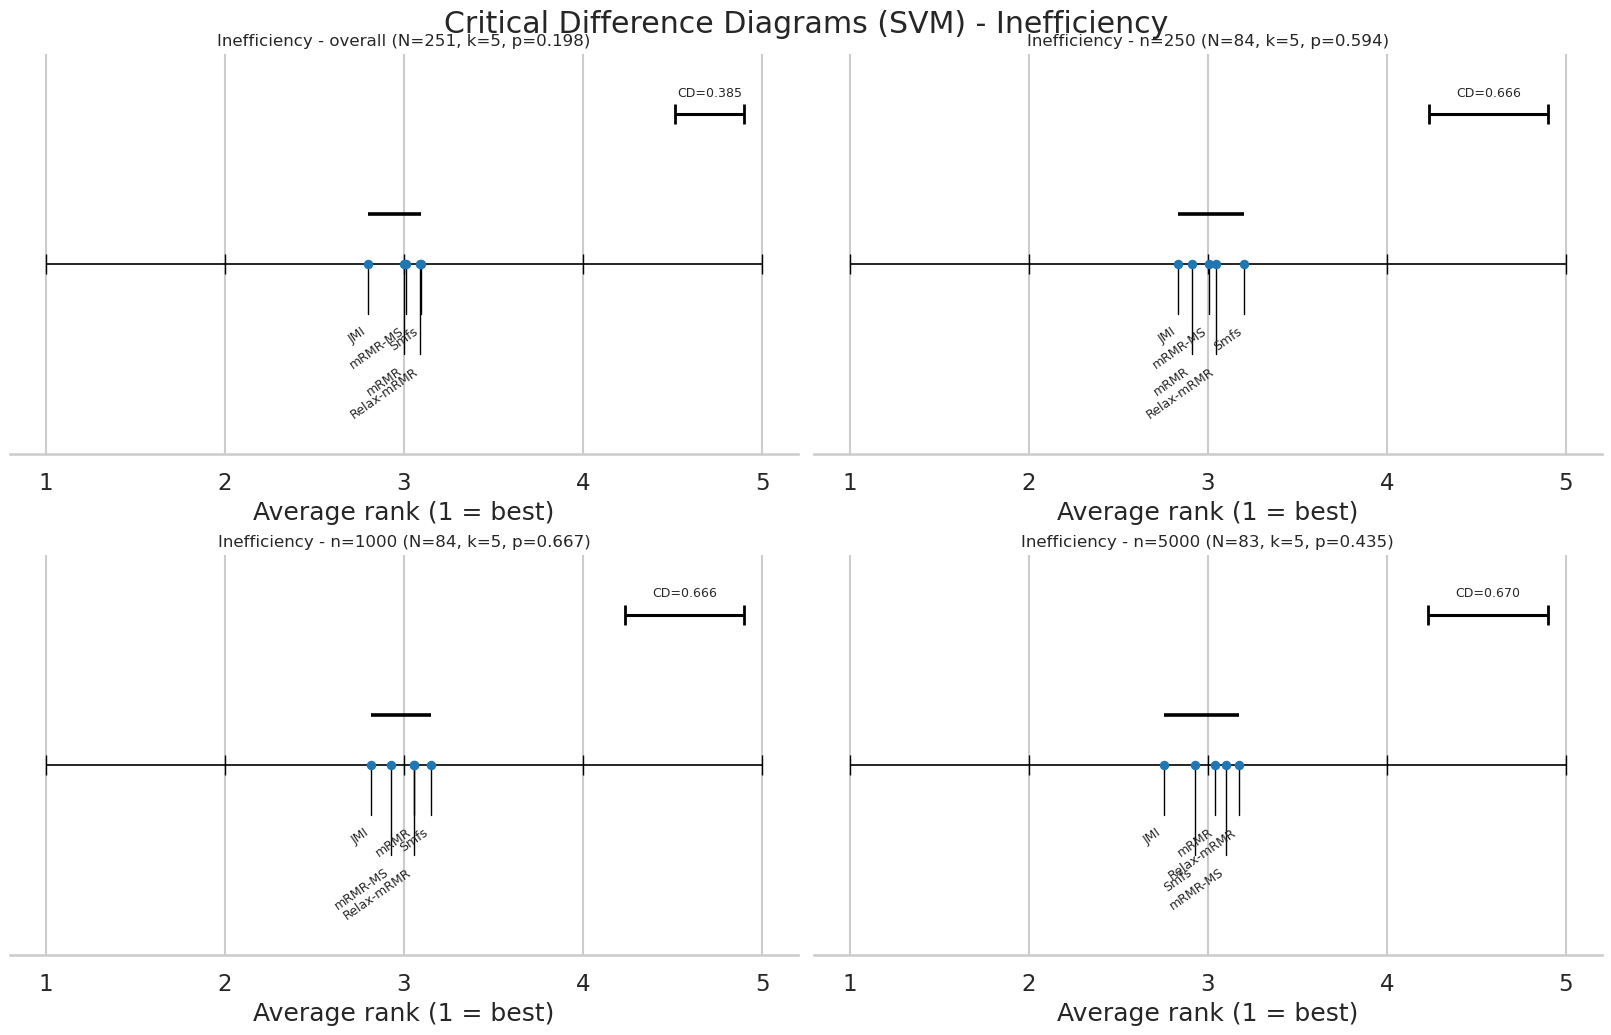

In [11]:
# Critical difference diagrams for inefficiency
specs = [('overall', None), ('n=250', 250), ('n=1000', 1000), ('n=5000', 5000)]
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for i, (label, _) in enumerate(specs):
    ax = axes[i]
    if label not in rank_means_ineff:
        ax.text(0.5, 0.5, 'Not enough complete data', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    avg_ranks = rank_means_ineff[label]
    meta = rank_long_ineff[rank_long_ineff['subset'] == label].iloc[0]
    title = f'Inefficiency - {label} (N={int(meta['N_datasets'])}, k={int(meta['k_methods'])}, p={meta['friedman_p']:.3g})'
    plot_cd_diagram(avg_ranks, float(meta['critical_distance_0.05']), title, ax)

fig.suptitle('Critical Difference Diagrams (SVM) - Inefficiency', y=1.02)
# fig.savefig(OUTPUT_DIR / "svm_cd_diagrams_inefficiency.png", dpi=220, bbox_inches="tight")
plt.show()


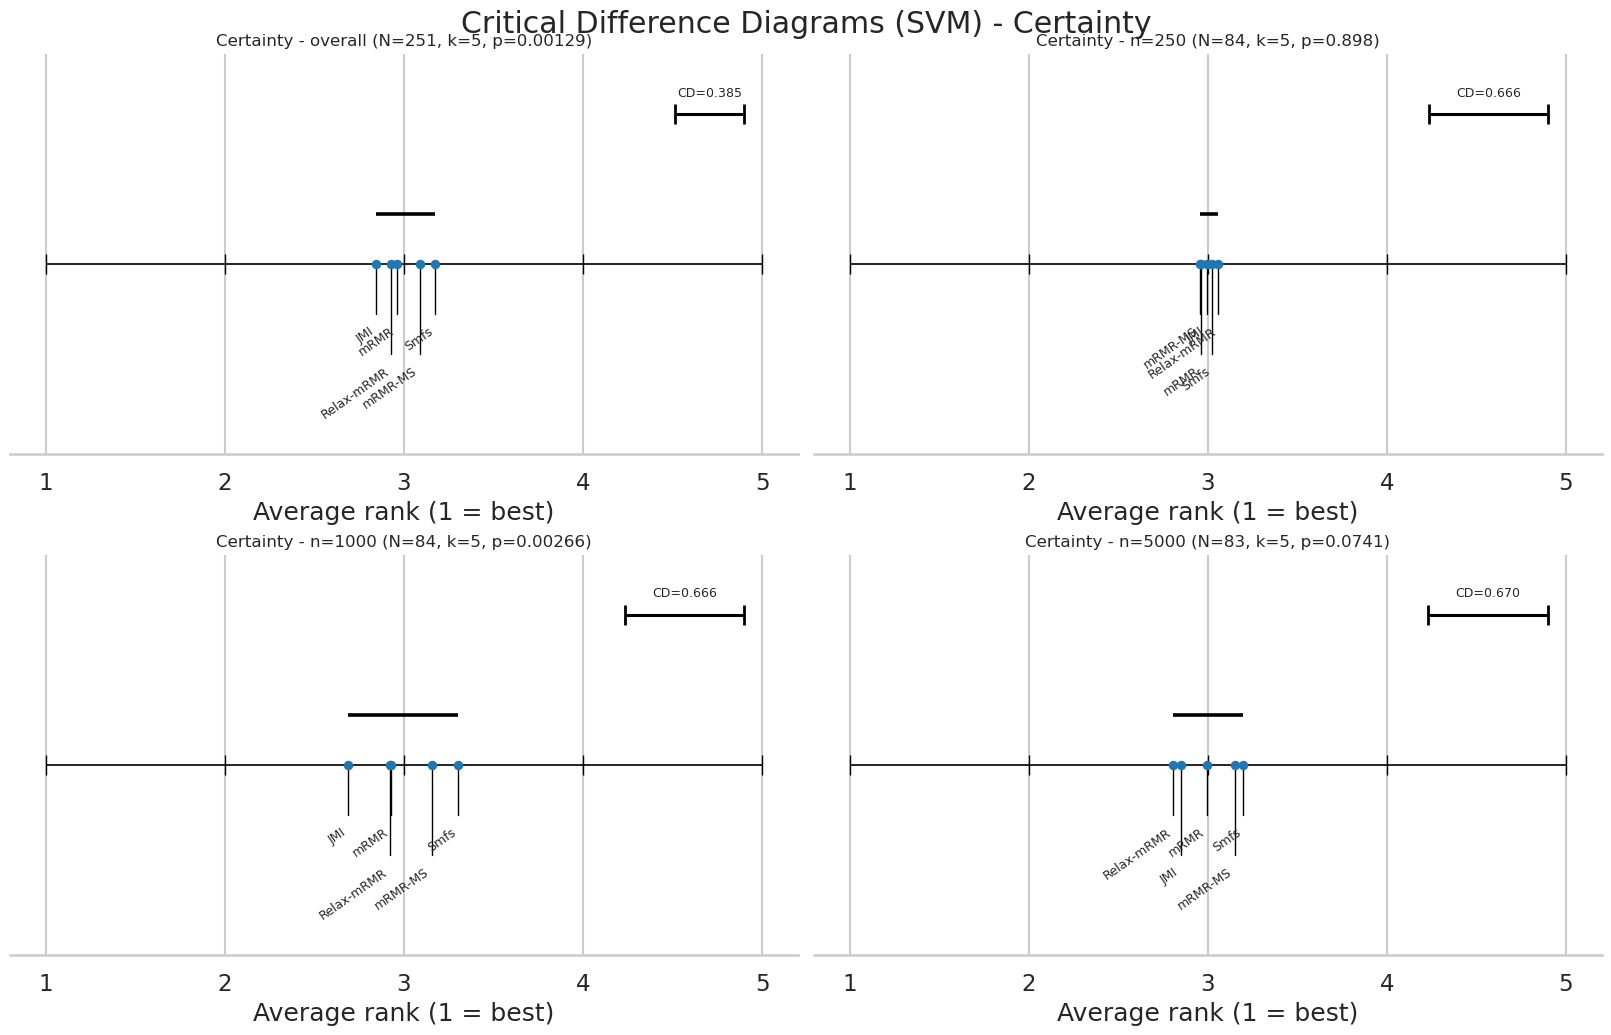

In [12]:
# Critical difference diagrams for certainty
specs = [('overall', None), ('n=250', 250), ('n=1000', 1000), ('n=5000', 5000)]
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for i, (label, _) in enumerate(specs):
    ax = axes[i]
    if label not in rank_means_cert:
        ax.text(0.5, 0.5, 'Not enough complete data', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    avg_ranks = rank_means_cert[label]
    meta = rank_long_cert[rank_long_cert['subset'] == label].iloc[0]
    title = f'Certainty - {label} (N={int(meta['N_datasets'])}, k={int(meta['k_methods'])}, p={meta['friedman_p']:.3g})'
    plot_cd_diagram(avg_ranks, float(meta['critical_distance_0.05']), title, ax)

fig.suptitle('Critical Difference Diagrams (SVM) - Certainty', y=1.02)
# fig.savefig(OUTPUT_DIR / "svm_cd_diagrams_certainty.png", dpi=220, bbox_inches="tight")
plt.show()


## Network-Level Comparisons

These views are easier to read than the global boxplots because they compare methods within each network.

- The heatmaps show average ranks per network and sample size.
- The win/tie/loss tables compare each method against a configurable reference method using paired targets within each network.


In [13]:
# Configurable reference for win/tie/loss summaries
REFERENCE_METHOD = 'Smfs'
TIE_TOL = 1e-6


def compute_network_average_ranks(data: pd.DataFrame, metric: str, ascending: bool) -> pd.DataFrame:
    rows = []
    for n_samples in SAMPLE_SIZES:
        sub = data[data['n_samples'] == n_samples].copy()
        for network_name, network_df in sub.groupby('network_name'):
            pivot = (
                network_df.groupby(['target_name', 'replication_id', 'method'], as_index=False)[metric]
                .mean()
                .pivot_table(
                    index=['target_name', 'replication_id'],
                    columns='method',
                    values=metric,
                    aggfunc='mean',
                )
            )
            matrix = pivot.dropna()
            if matrix.empty or matrix.shape[1] < 2:
                continue

            # Within-network paired ranks are computed per (target_name, replication_id)
            # before averaging across the available paired targets.
            rank_df = matrix.rank(axis=1, ascending=ascending, method='average')
            avg_ranks = rank_df.mean(axis=0)
            for method, avg_rank in avg_ranks.items():
                rows.append(
                    {
                        'metric': metric,
                        'n_samples': n_samples,
                        'network_name': network_name,
                        'method': method,
                        'avg_rank': avg_rank,
                        'n_pairs': matrix.shape[0],
                        'k_methods': matrix.shape[1],
                    }
                )
    return pd.DataFrame(rows)


def plot_network_rank_heatmaps(network_rank_df: pd.DataFrame, title_prefix: str):
    if network_rank_df.empty:
        raise ValueError(f'No network rank data available for {title_prefix}.')

    method_order = (
        network_rank_df.groupby('method')['avg_rank']
        .mean()
        .sort_values()
        .index
        .tolist()
    )
    network_order = sorted(network_rank_df['network_name'].unique().tolist())
    cmap = LinearSegmentedColormap.from_list(
        'nature_rank',
        ['#F3EFE3', '#CBD8C3', '#7EA083', '#2E5646']
    )

    fig, axes = plt.subplots(1, 3, figsize=(24, 8.5), constrained_layout=True)
    fig.patch.set_facecolor('#F7F3EA')

    for idx, n_samples in enumerate(SAMPLE_SIZES):
        ax = axes[idx]
        ax.set_facecolor('#F7F3EA')
        heat = (
            network_rank_df[network_rank_df['n_samples'] == n_samples]
            .pivot(index='network_name', columns='method', values='avg_rank')
            .reindex(index=network_order, columns=method_order)
        )
        if heat.dropna(how='all').empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes, fontsize=13)
            ax.set_axis_off()
            continue

        avg_row = pd.DataFrame([heat.mean(axis=0)], index=['Average'])
        heat_display = pd.concat([heat, avg_row], axis=0)

        sns.heatmap(
            heat_display,
            annot=True,
            fmt='.2f',
            cmap=cmap,
            vmin=1,
            vmax=len(method_order),
            linewidths=0.9,
            linecolor='#E7E0D1',
            cbar=(idx == len(SAMPLE_SIZES) - 1),
            cbar_kws={'label': 'Average rank (1 = best)', 'shrink': 0.78},
            annot_kws={'fontsize': 13, 'color': '#10231B', 'fontweight': 'bold'},
            ax=ax,
        )

        ax.set_title(f'{title_prefix}\n$n = {n_samples}$', fontsize=15, fontweight='semibold', pad=12)
        ax.set_xlabel('Method', fontsize=12, fontweight='bold')
        ax.set_ylabel('Network' if idx == 0 else '', fontsize=12, fontweight='bold')
        ax.tick_params(axis='x', rotation=32, labelsize=12)
        ax.tick_params(axis='y', rotation=0, labelsize=12)
        for label in ax.get_xticklabels():
            label.set_fontweight('bold')
        for label in ax.get_yticklabels():
            label.set_fontweight('bold')
        for text in ax.texts:
            text.set_fontweight('bold')

        for spine in ax.spines.values():
            spine.set_visible(False)

    return fig, method_order


def compute_network_wtl(
    data: pd.DataFrame,
    metric: str,
    reference_method: str,
    ascending: bool,
    tie_tol: float = 1e-6,
) -> pd.DataFrame:
    rows = []
    for n_samples in SAMPLE_SIZES:
        sub = data[data['n_samples'] == n_samples].copy()
        for network_name, network_df in sub.groupby('network_name'):
            pivot = (
                network_df.groupby(['target_name', 'replication_id', 'method'], as_index=False)[metric]
                .mean()
                .pivot_table(
                    index=['target_name', 'replication_id'],
                    columns='method',
                    values=metric,
                    aggfunc='mean',
                )
            )
            if reference_method not in pivot.columns:
                continue

            for method in pivot.columns:
                if method == reference_method:
                    continue
                pair = pivot[[reference_method, method]].dropna()
                if pair.empty:
                    continue

                diff = pair[method] - pair[reference_method]
                if ascending:
                    wins = int((diff < -tie_tol).sum())
                    losses = int((diff > tie_tol).sum())
                else:
                    wins = int((diff > tie_tol).sum())
                    losses = int((diff < -tie_tol).sum())
                ties = int((diff.abs() <= tie_tol).sum())

                rows.append(
                    {
                        'metric': metric,
                        'n_samples': n_samples,
                        'network_name': network_name,
                        'reference_method': reference_method,
                        'method': method,
                        'wins': wins,
                        'ties': ties,
                        'losses': losses,
                        'net_wins': wins - losses,
                        'n_pairs': int(len(pair)),
                    }
                )
    return pd.DataFrame(rows)


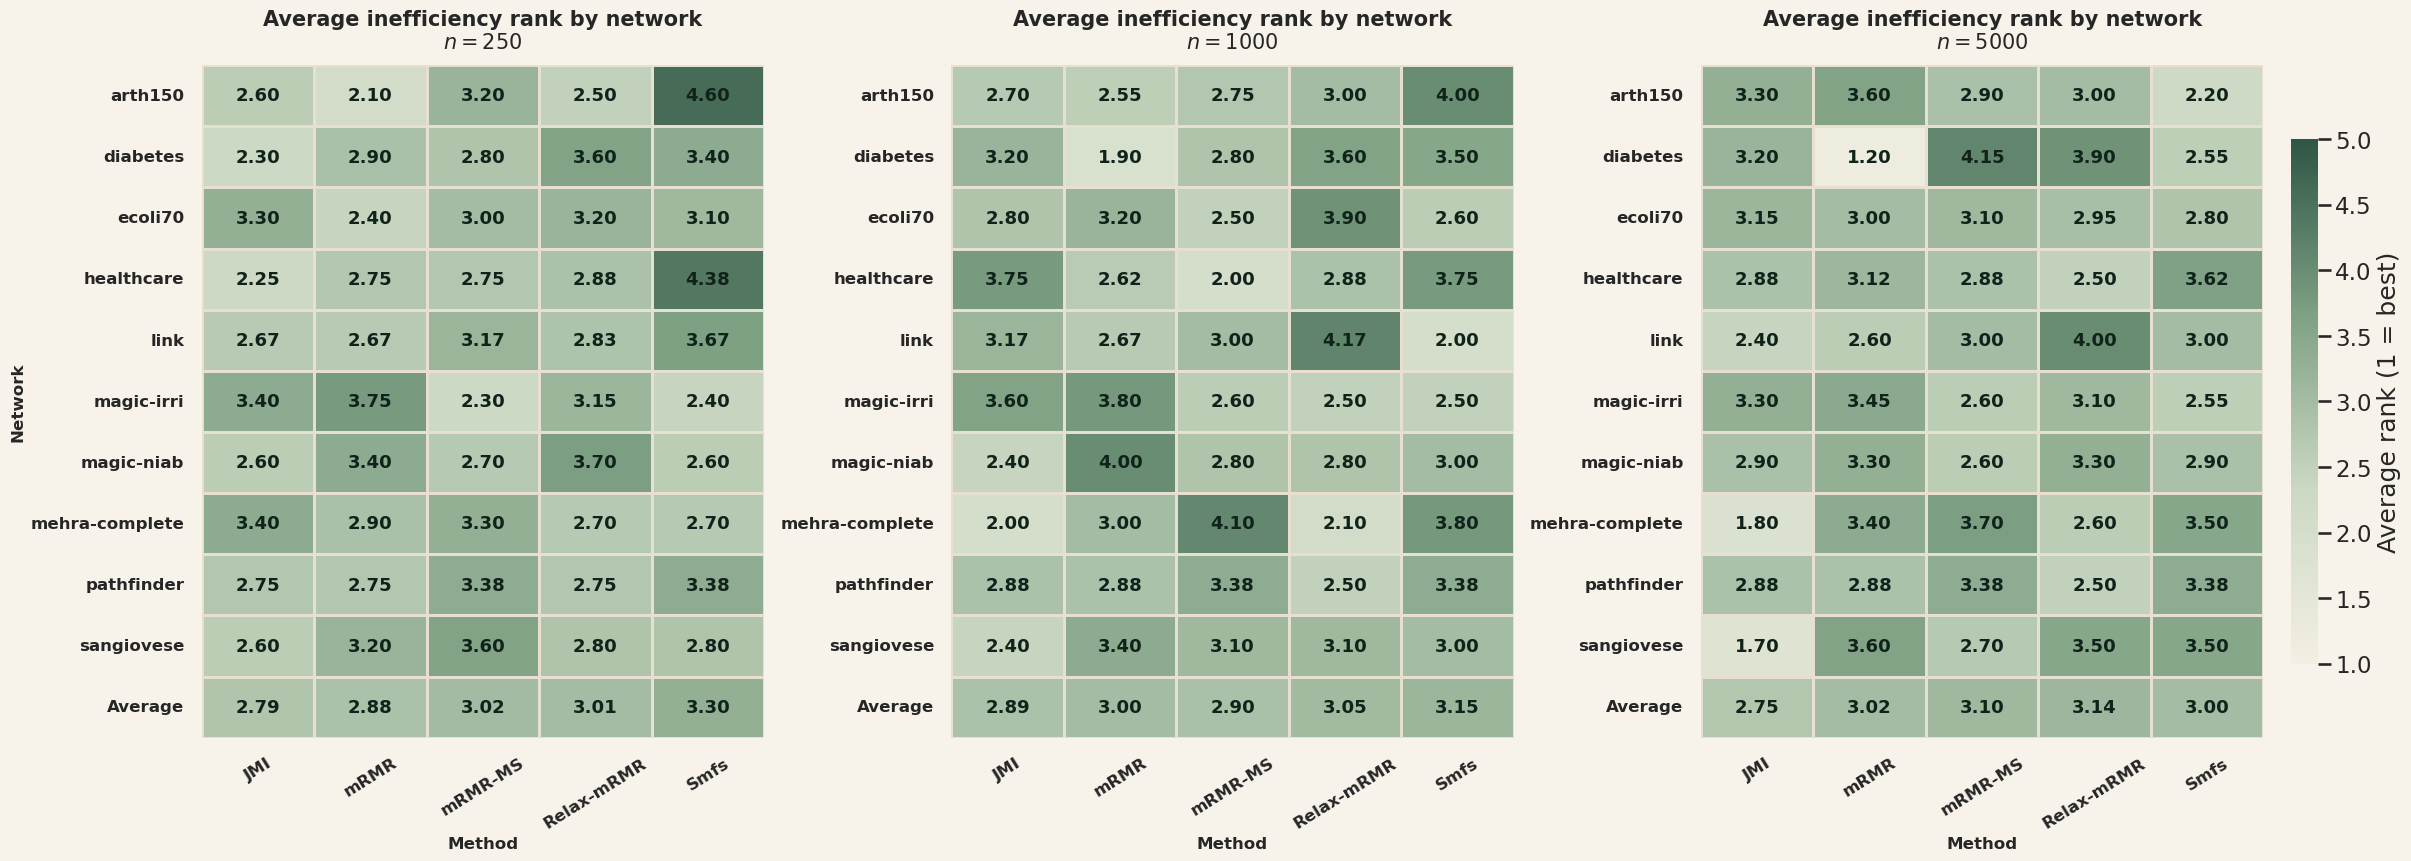

In [14]:
# Per-network average-rank heatmaps for inefficiency
network_rank_ineff = compute_network_average_ranks(
    plot_df,
    metric='mean_inefficiency',
    ascending=True,
)
fig, network_order_ineff = plot_network_rank_heatmaps(
    network_rank_ineff,
    title_prefix='Average inefficiency rank by network',
)
# fig.savefig(OUTPUT_DIR / "svm_network_rank_heatmap_inefficiency.png", dpi=220, bbox_inches="tight")
plt.show()


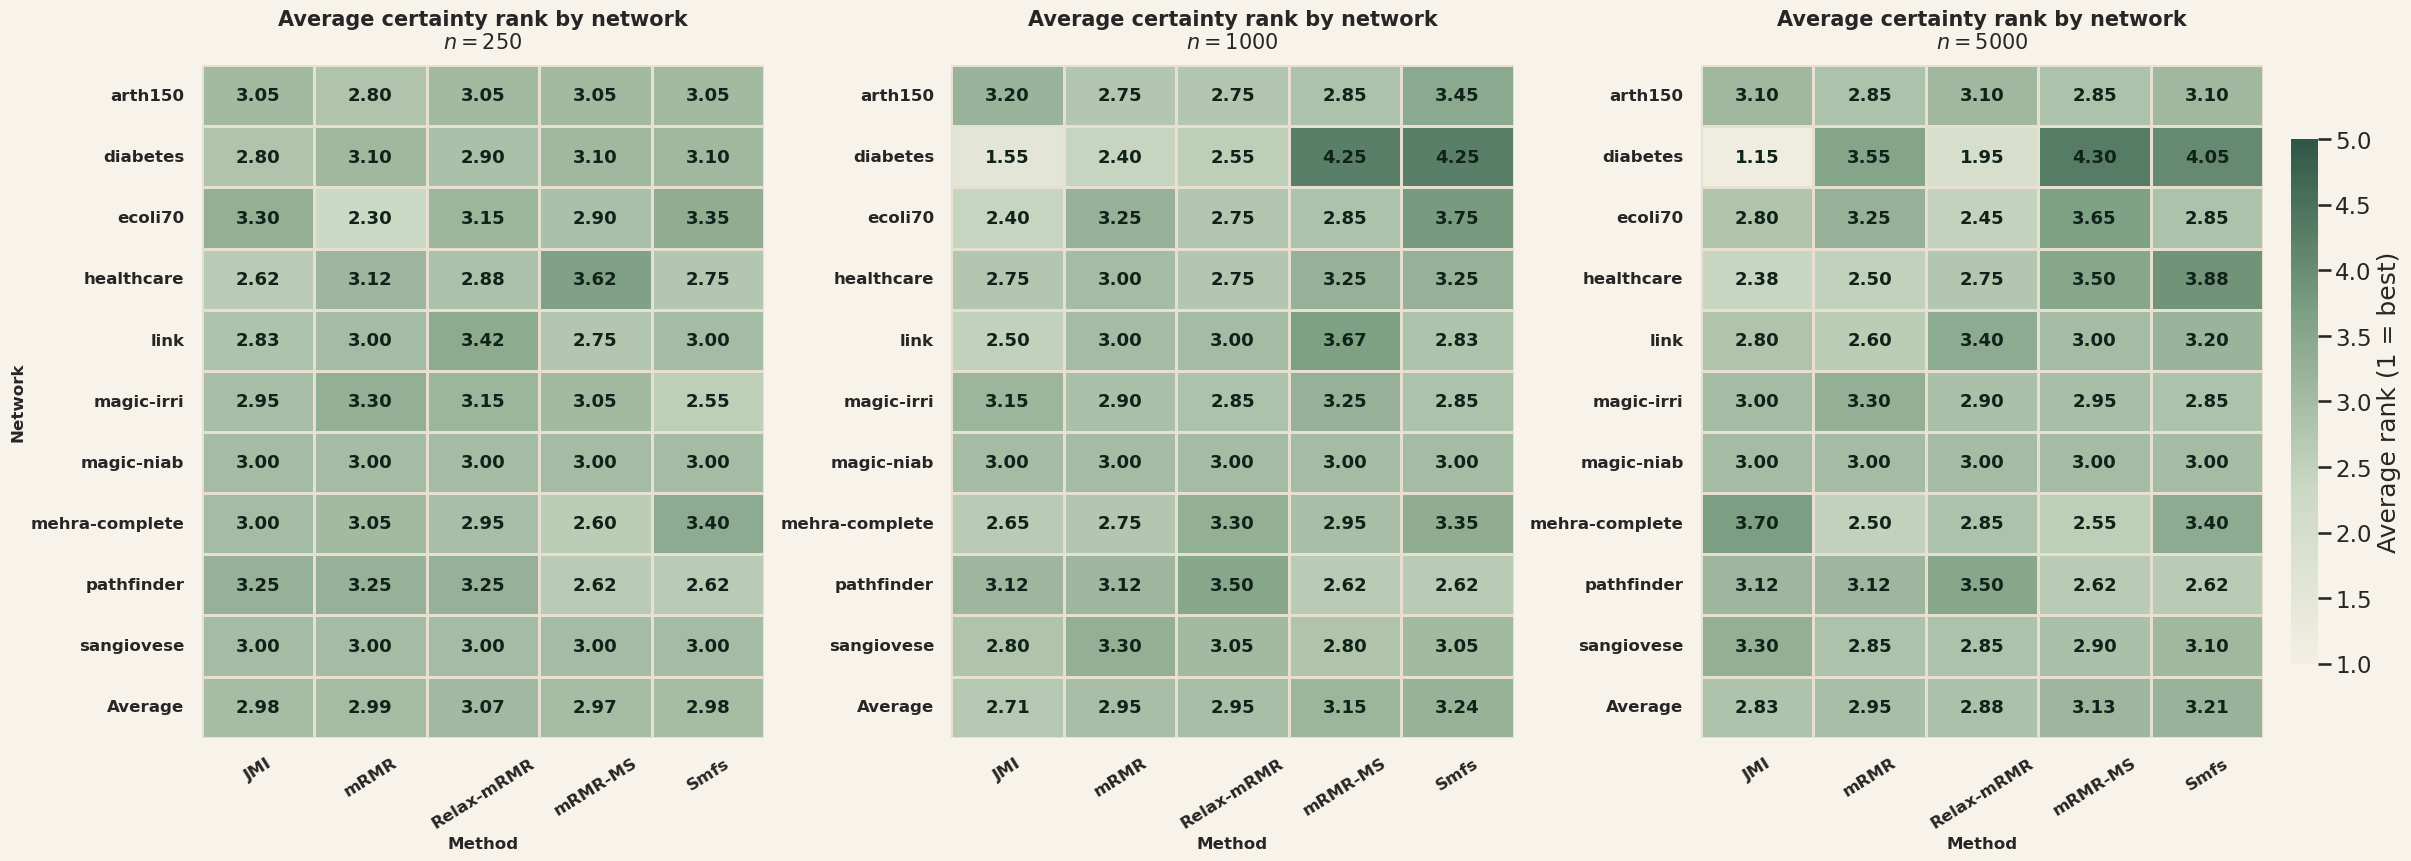

In [15]:
# Per-network average-rank heatmaps for certainty
network_rank_cert = compute_network_average_ranks(
    plot_df,
    metric='mean_certainty',
    ascending=False,
)
fig, network_order_cert = plot_network_rank_heatmaps(
    network_rank_cert,
    title_prefix='Average certainty rank by network',
)
# fig.savefig(OUTPUT_DIR / "svm_network_rank_heatmap_certainty.png", dpi=220, bbox_inches="tight")
plt.show()


In [16]:
# Win/tie/loss summary for inefficiency relative to the reference method
wtl_ineff = compute_network_wtl(
    plot_df,
    metric='mean_inefficiency',
    reference_method=REFERENCE_METHOD,
    ascending=True,
    tie_tol=TIE_TOL,
)
wtl_ineff_summary = (
    wtl_ineff.groupby(['n_samples', 'method'], as_index=False)
    .agg(
        wins=('wins', 'sum'),
        ties=('ties', 'sum'),
        losses=('losses', 'sum'),
        net_wins=('net_wins', 'sum'),
        n_pairs=('n_pairs', 'sum'),
    )
    .sort_values(['n_samples', 'net_wins', 'wins'], ascending=[True, False, False])
    .reset_index(drop=True)
)

print(f'Inefficiency win/tie/loss against {REFERENCE_METHOD}:')
print(wtl_ineff_summary.to_string(index=False))

wtl_ineff_by_network = (
    wtl_ineff.pivot_table(index=['n_samples', 'network_name'], columns='method', values='net_wins', aggfunc='sum')
    .sort_index()
)
wtl_ineff_by_network

# wtl_ineff_summary.to_csv(OUTPUT_DIR / "svm_wtl_inefficiency_vs_reference.csv", index=False)


Inefficiency win/tie/loss against Smfs:
 n_samples     method  wins  ties  losses  net_wins  n_pairs
       250        JMI    46     4      34        12       84
       250    mRMR-MS    46     4      34        12       84
       250       mRMR    44     4      36         8       84
       250 Relax-mRMR    41     4      39         2       84
      1000        JMI    47     4      33        14       84
      1000    mRMR-MS    44     6      34        10       84
      1000 Relax-mRMR    43     4      37         6       84
      1000       mRMR    37     4      43        -6       84
      5000        JMI    41     3      39         2       83
      5000       mRMR    40     4      39         1       83
      5000    mRMR-MS    35     6      42        -7       83
      5000 Relax-mRMR    36     3      44        -8       83


method                    JMI  Relax-mRMR  mRMR  mRMR-MS
n_samples network_name                                  
250       arth150           8           8    10        6
          diabetes          2           0     4        2
          ecoli70           0          -2     2        2
          healthcare        3           3     3        2
          link              4           0     2        2
          magic-irri       -4          -4    -4        0
          magic-niab       -2          -4    -4        2
          mehra-complete   -2           0    -2       -2
          pathfinder        1           1     1        0
          sangiovese        2           0    -4       -2
1000      arth150           6           6     4        4
          diabetes          2           0     4        4
          ecoli70           0          -4    -6        1
          healthcare        1           1     1        3
          link             -2          -4    -2       -4
          magic-irri       -6           0    -6        2
          magic-niab        2           0    -4        2
          mehra-complete    6           6     6       -2
          pathfinder        1           1     1        0
          sangiovese        4           0    -4        0
5000      arth150          -6          -4    -2       -4
          diabetes         -4          -4     6       -7
          ecoli70           0          -2    -2        0
          healthcare        0           2     2        1
          link              1          -1    -1        1
          magic-irri       -2          -4    -5        2
          magic-niab        0          -2     0        0
          mehra-complete    6           6     2       -4
          pathfinder        1           1     1        0
          sangiovese        6           0     0        4

In [17]:
# Win/tie/loss summary for certainty relative to the reference method
wtl_cert = compute_network_wtl(
    plot_df,
    metric='mean_certainty',
    reference_method=REFERENCE_METHOD,
    ascending=False,
    tie_tol=TIE_TOL,
)
wtl_cert_summary = (
    wtl_cert.groupby(['n_samples', 'method'], as_index=False)
    .agg(
        wins=('wins', 'sum'),
        ties=('ties', 'sum'),
        losses=('losses', 'sum'),
        net_wins=('net_wins', 'sum'),
        n_pairs=('n_pairs', 'sum'),
    )
    .sort_values(['n_samples', 'net_wins', 'wins'], ascending=[True, False, False])
    .reset_index(drop=True)
)

print(f'Certainty win/tie/loss against {REFERENCE_METHOD}:')
print(wtl_cert_summary.to_string(index=False))

wtl_cert_by_network = (
    wtl_cert.pivot_table(index=['n_samples', 'network_name'], columns='method', values='net_wins', aggfunc='sum')
    .sort_index()
)
wtl_cert_by_network

# wtl_cert_summary.to_csv(OUTPUT_DIR / "svm_wtl_certainty_vs_reference.csv", index=False)


Certainty win/tie/loss against Smfs:
 n_samples     method  wins  ties  losses  net_wins  n_pairs
       250       mRMR    10    66       8         2       84
       250    mRMR-MS    10    66       8         2       84
       250        JMI     9    66       9         0       84
       250 Relax-mRMR     9    66       9         0       84
      1000        JMI    27    48       9        18       84
      1000 Relax-mRMR    25    49      10        15       84
      1000       mRMR    25    49      10        15       84
      1000    mRMR-MS    15    57      12         3       84
      5000 Relax-mRMR    29    41      13        16       83
      5000        JMI    25    42      16         9       83
      5000       mRMR    21    46      16         5       83
      5000    mRMR-MS    18    49      16         2       83


method                    JMI  Relax-mRMR  mRMR  mRMR-MS
n_samples network_name                                  
250       arth150           0           0     1        0
          diabetes          1           1     0        0
          ecoli70          -1           2     4        2
          healthcare        0           0     0       -2
          link              0          -1     0        1
          magic-irri       -1          -3    -3       -2
          magic-niab        0           0     0        0
          mehra-complete    2           2     1        3
          pathfinder       -1          -1    -1        0
          sangiovese        0           0     0        0
1000      arth150           1           3     3        2
          diabetes          9           8     8        0
          ecoli70           4           4     3        4
          healthcare        2           0     0        0
          link              0           0     0       -2
          magic-irri       -1           1    -1       -2
          magic-niab        0           0     0        0
          mehra-complete    3           0     4        0
          pathfinder       -1          -1    -1        0
          sangiovese        1           0    -1        1
5000      arth150           0           0     1        1
          diabetes         10          10     3       -2
          ecoli70          -1           3    -2       -3
          healthcare        2           2     2        1
          link              1          -1     1        0
          magic-irri        0           0    -2       -1
          magic-niab        0           0     0        0
          mehra-complete   -2           2     2        6
          pathfinder       -1          -1    -1        0
          sangiovese        0           1     1        0

## MB Detection vs Predictive Utility

This section contrasts structural Markov blanket recovery with downstream predictive behavior.

- Structural metrics come from `markov_blanket_detection_summary.csv`.
- Predictive metrics come from the SVM rows of `mb_cardinality_metrics_summary.csv`.
- The same filtered method set is used here as in the rest of the notebook.
- Comparisons are aligned at the paired experimental-unit level before aggregation.

In [18]:
def collect_mb_detection_metrics(results_root: Path) -> pd.DataFrame:
    rows = []
    for save_dir in sorted(results_root.glob('save_*')):
        if not save_dir.is_dir():
            continue

        dataset_name = save_dir.name.replace('save_', '')
        for run_dir in sorted(save_dir.iterdir()):
            if not run_dir.is_dir():
                continue

            m = FOLDER_PATTERN.match(run_dir.name)
            if not m:
                continue

            csv_path = run_dir / 'results' / 'markov_blanket_detection_summary.csv'
            if not csv_path.exists():
                continue

            df = pd.read_csv(csv_path)
            if df.empty:
                continue

            df = df.copy()
            df['dataset_name'] = dataset_name
            df['network_name'] = m.group('network')
            df['target_name'] = m.group('target')
            df['n_samples'] = int(m.group('n_samples'))
            df['replication_id'] = int(m.group('rep'))
            rows.append(df)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out['method'] = out['method_output_name'].map(METHOD_ALIAS).fillna(out['method_output_name'])

    for col in [
        'mb_size', 'mean_recall_mb_grouped', 'mean_precision_mb_grouped',
        'exact_match_rate_grouped', 'mean_recall_mb_raw', 'exact_match_rate_raw', 'n_samples'
    ]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')

    return out


mb_detect_raw_df = collect_mb_detection_metrics(RESULTS_ROOT)
if mb_detect_raw_df.empty:
    raise ValueError('No markov_blanket_detection_summary.csv data found.')

mb_detect_obs_df = (
    mb_detect_raw_df
    .dropna(subset=['method', 'mean_recall_mb_grouped', 'mean_precision_mb_grouped'])
    .groupby(
        ['dataset_name', 'network_name', 'target_name', 'n_samples', 'replication_id', 'mb_size', 'method'],
        as_index=False
    )[[
        'mean_recall_mb_grouped', 'mean_precision_mb_grouped', 'exact_match_rate_grouped',
        'mean_recall_mb_raw', 'exact_match_rate_raw'
    ]]
    .mean()
)

mb_plot_df = mb_detect_obs_df.loc[~mb_detect_obs_df['method'].isin(PLOT_METHOD_EXCLUDE)].copy()
comparison_df = plot_df.merge(
    mb_plot_df,
    on=['dataset_name', 'network_name', 'target_name', 'n_samples', 'replication_id', 'mb_size', 'method'],
    how='inner',
)

print(f'MB detection rows loaded: {len(mb_detect_obs_df):,}')
print(f'Paired rows for structural/predictive comparison: {len(comparison_df):,}')
print('Methods in MB comparison:', sorted(comparison_df['method'].dropna().unique().tolist()))
comparison_df.head()


MB detection rows loaded: 1,766
Paired rows for structural/predictive comparison: 1,255
Methods in MB comparison: ['JMI', 'Relax-mRMR', 'Smfs', 'mRMR', 'mRMR-MS']


,dataset_name,network_name,target_name,n_samples,replication_id,mb_size,method,mean_inefficiency,mean_certainty,mean_recall_mb_grouped,mean_precision_mb_grouped,exact_match_rate_grouped,mean_recall_mb_raw,exact_match_rate_raw
0,arth150,arth150,108,250,1,6,JMI,8.2517,0.0000,0.3333,0.3333,0.0000,0.3333,0.0000
1,arth150,arth150,108,250,1,6,Relax-mRMR,8.1957,0.0000,0.2917,0.2917,0.0000,0.2917,0.0000
2,arth150,arth150,108,250,1,6,Smfs,9.1933,0.0000,0.1250,0.1250,0.0000,0.1250,0.0000
3,arth150,arth150,108,250,1,6,mRMR,7.9898,0.0000,0.2500,0.2500,0.0000,0.2500,0.0000
4,arth150,arth150,108,250,1,6,mRMR-MS,8.4363,0.0000,0.2500,0.2500,0.0000,0.2500,0.0000


In [19]:
# Overall method-level contrast between MB detection and predictive behavior
mb_predictive_summary = (
    comparison_df.groupby('method', as_index=False)
    .agg(
        n_obs=('mean_inefficiency', 'size'),
        avg_mb_recall_grouped=('mean_recall_mb_grouped', 'mean'),
        avg_mb_precision_grouped=('mean_precision_mb_grouped', 'mean'),
        avg_exact_match_grouped=('exact_match_rate_grouped', 'mean'),
        avg_inefficiency=('mean_inefficiency', 'mean'),
        avg_certainty=('mean_certainty', 'mean'),
    )
    .sort_values(['avg_mb_recall_grouped', 'avg_certainty'], ascending=[False, False])
    .reset_index(drop=True)
)

# mb_predictive_summary.to_csv(OUTPUT_DIR / 'svm_mb_detection_vs_predictive_summary.csv', index=False)
mb_predictive_summary


,method,n_obs,avg_mb_recall_grouped,avg_mb_precision_grouped,avg_exact_match_grouped,avg_inefficiency,avg_certainty
0,JMI,251,0.5349,0.5349,0.0179,6.7784,0.0581
1,mRMR-MS,251,0.4950,0.4950,0.0060,6.8449,0.0520
2,Relax-mRMR,251,0.4775,0.4775,0.0120,6.8098,0.0563
3,mRMR,251,0.4540,0.4540,0.0060,6.7727,0.0547
4,Smfs,251,0.4280,0.4280,0.0050,6.8416,0.0524


In [20]:
# Correlation between grouped MB recall and predictive metrics at the paired observation level
corr_summary = (
    comparison_df[['mean_recall_mb_grouped', 'mean_inefficiency', 'mean_certainty']]
    .corr(method='spearman')
)
corr_summary


,mean_recall_mb_grouped,mean_inefficiency,mean_certainty
mean_recall_mb_grouped,1.0000,-0.2154,0.2739
mean_inefficiency,-0.2154,1.0000,-0.5058
mean_certainty,0.2739,-0.5058,1.0000


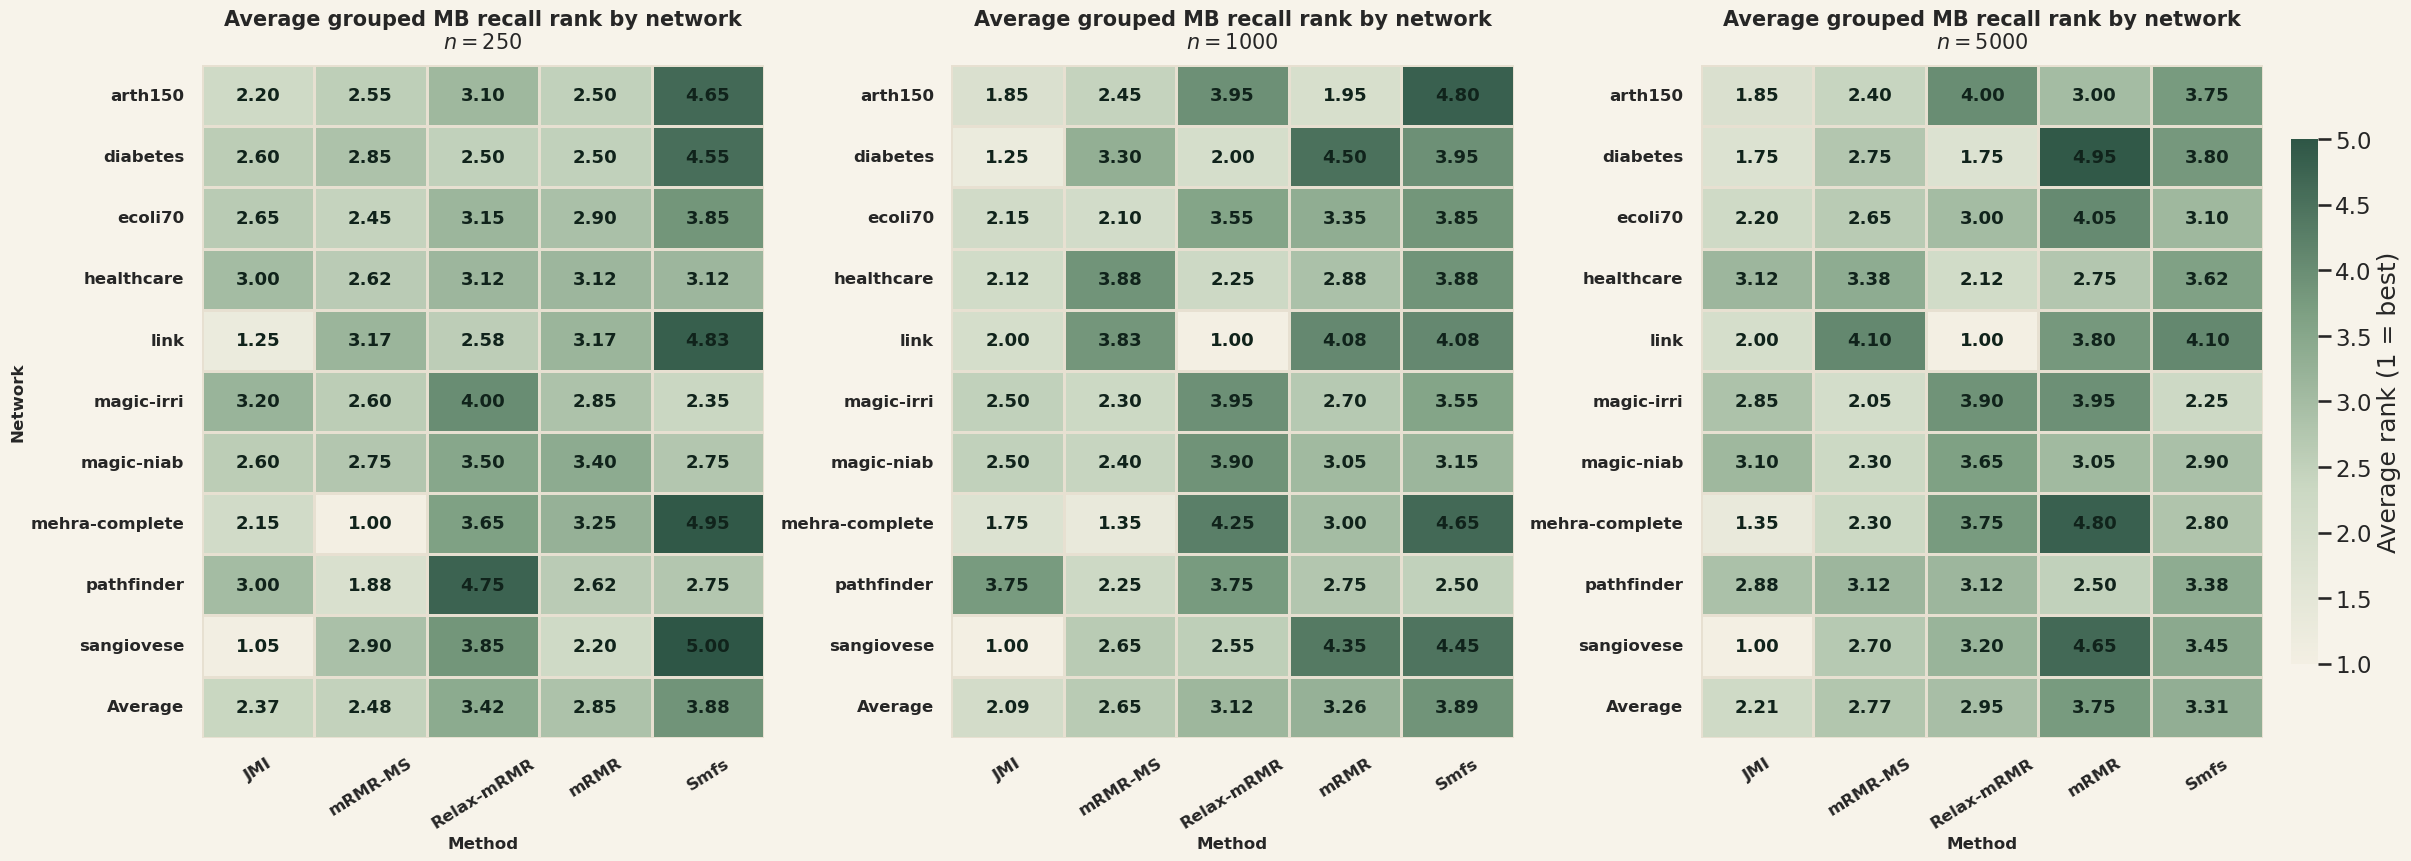

In [21]:
# Per-network average-rank heatmaps for grouped MB recall
network_rank_mb_recall = compute_network_average_ranks(
    comparison_df,
    metric='mean_recall_mb_grouped',
    ascending=False,
)
fig, network_order_mb_recall = plot_network_rank_heatmaps(
    network_rank_mb_recall,
    title_prefix='Average grouped MB recall rank by network',
)
# fig.savefig(OUTPUT_DIR / 'svm_network_rank_heatmap_mb_recall_grouped.png', dpi=220, bbox_inches='tight')
plt.show()


In [22]:
# Direct rank contrast: structural recall vs predictive utility by method and sample size
rank_alignment_summary = (
    network_rank_mb_recall
    .rename(columns={'avg_rank': 'mb_recall_rank'})
    .merge(
        network_rank_ineff.rename(columns={'avg_rank': 'inefficiency_rank'})[['n_samples', 'network_name', 'method', 'inefficiency_rank']],
        on=['n_samples', 'network_name', 'method'],
        how='inner',
    )
    .merge(
        network_rank_cert.rename(columns={'avg_rank': 'certainty_rank'})[['n_samples', 'network_name', 'method', 'certainty_rank']],
        on=['n_samples', 'network_name', 'method'],
        how='inner',
    )
)
rank_alignment_summary['delta_recall_vs_ineff'] = rank_alignment_summary['mb_recall_rank'] - rank_alignment_summary['inefficiency_rank']
rank_alignment_summary['delta_recall_vs_cert'] = rank_alignment_summary['mb_recall_rank'] - rank_alignment_summary['certainty_rank']

rank_alignment_by_method = (
    rank_alignment_summary.groupby(['n_samples', 'method'], as_index=False)
    .agg(
        avg_mb_recall_rank=('mb_recall_rank', 'mean'),
        avg_inefficiency_rank=('inefficiency_rank', 'mean'),
        avg_certainty_rank=('certainty_rank', 'mean'),
        avg_delta_recall_vs_ineff=('delta_recall_vs_ineff', 'mean'),
        avg_delta_recall_vs_cert=('delta_recall_vs_cert', 'mean'),
    )
    .sort_values(['n_samples', 'avg_mb_recall_rank'])
    .reset_index(drop=True)
)

# rank_alignment_by_method.to_csv(OUTPUT_DIR / 'svm_rank_alignment_mb_vs_predictive.csv', index=False)
rank_alignment_by_method


,n_samples,method,avg_mb_recall_rank,avg_inefficiency_rank,avg_certainty_rank,avg_delta_recall_vs_ineff,avg_delta_recall_vs_cert
0,250,JMI,2.3700,2.7867,2.9808,-0.4167,-0.6108
1,250,mRMR-MS,2.4767,3.0192,2.9700,-0.5425,-0.4933
2,250,mRMR,2.8517,2.8817,2.9925,-0.0300,-0.1408
3,250,Relax-mRMR,3.4208,3.0108,3.0742,0.4100,0.3467
4,250,Smfs,3.8808,3.3017,2.9825,0.5792,0.8983
5,1000,JMI,2.0875,2.8892,2.7125,-0.8017,-0.6250
6,1000,mRMR-MS,2.6508,2.9025,3.1492,-0.2517,-0.4983
7,1000,Relax-mRMR,3.1150,3.0542,2.9500,0.0608,0.1650
8,1000,mRMR,3.2608,3.0017,2.9475,0.2592,0.3133
9,1000,Smfs,3.8858,3.1525,3.2408,0.7333,0.6450


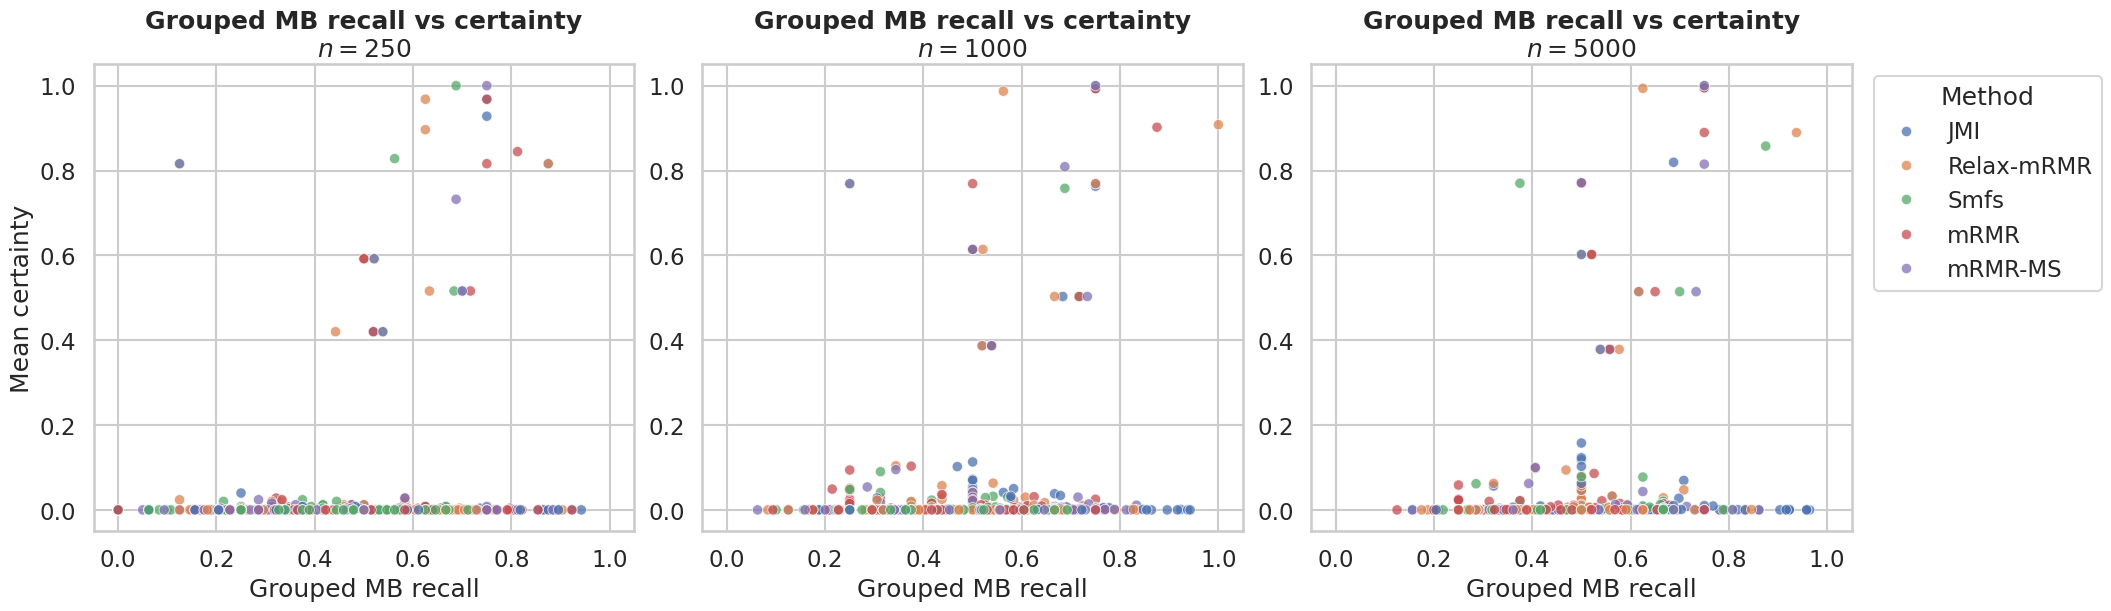

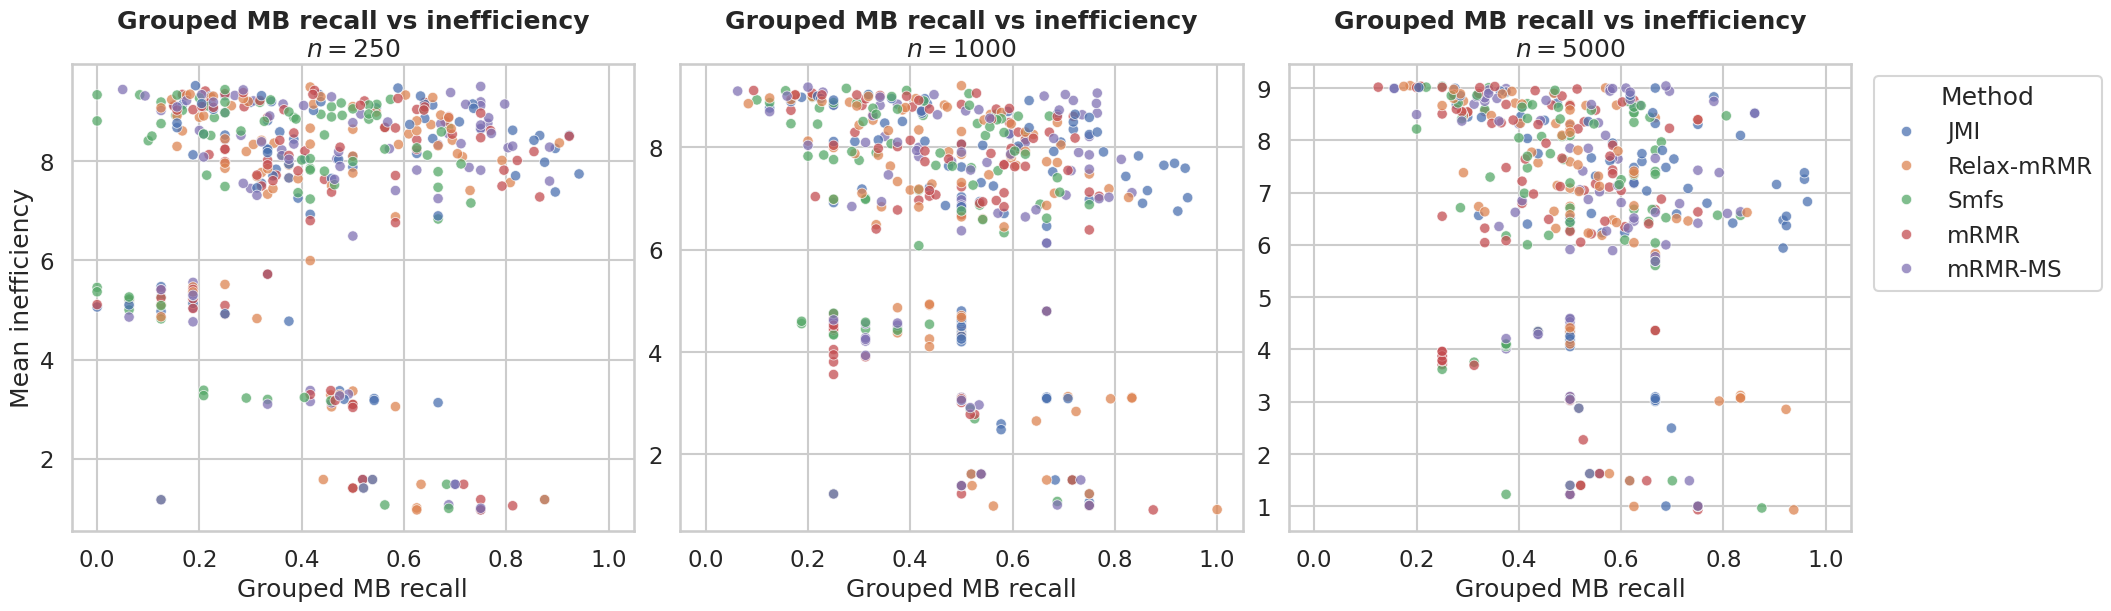

In [23]:
# Scatter views: does better MB recall align with better predictive behavior?
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, constrained_layout=True)
palette = sns.color_palette('deep', n_colors=comparison_df['method'].nunique())
method_palette = dict(zip(sorted(comparison_df['method'].unique()), palette))

for i, n in enumerate(SAMPLE_SIZES):
    ax = axes[i]
    sub = comparison_df[comparison_df['n_samples'] == n].copy()
    if sub.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    sns.scatterplot(
        data=sub,
        x='mean_recall_mb_grouped',
        y='mean_certainty',
        hue='method',
        palette=method_palette,
        alpha=0.75,
        s=55,
        ax=ax,
    )
    ax.set_title(f'Grouped MB recall vs certainty\n$n = {n}$', fontweight='bold')
    ax.set_xlabel('Grouped MB recall')
    ax.set_ylabel('Mean certainty' if i == 0 else '')
    if i != len(SAMPLE_SIZES) - 1:
        ax.get_legend().remove()

handles, labels = axes[-1].get_legend_handles_labels()
if handles:
    axes[-1].legend(handles, labels, title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
# fig.savefig(OUTPUT_DIR / 'svm_scatter_mb_recall_vs_certainty.png', dpi=220, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, constrained_layout=True)
for i, n in enumerate(SAMPLE_SIZES):
    ax = axes[i]
    sub = comparison_df[comparison_df['n_samples'] == n].copy()
    if sub.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    sns.scatterplot(
        data=sub,
        x='mean_recall_mb_grouped',
        y='mean_inefficiency',
        hue='method',
        palette=method_palette,
        alpha=0.75,
        s=55,
        ax=ax,
    )
    ax.set_title(f'Grouped MB recall vs inefficiency\n$n = {n}$', fontweight='bold')
    ax.set_xlabel('Grouped MB recall')
    ax.set_ylabel('Mean inefficiency' if i == 0 else '')
    if i != len(SAMPLE_SIZES) - 1:
        ax.get_legend().remove()

handles, labels = axes[-1].get_legend_handles_labels()
if handles:
    axes[-1].legend(handles, labels, title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
# fig.savefig(OUTPUT_DIR / 'svm_scatter_mb_recall_vs_inefficiency.png', dpi=220, bbox_inches='tight')
plt.show()


## Paper Reporting Notes

- Use `rank_table_ineff` and `rank_table_cert` for global average-rank reporting.
- Use `network_rank_ineff` and `network_rank_cert` heatmaps as the main figures when the global boxplots are hard to interpret.
- Use `wtl_ineff_summary` and `wtl_cert_summary` as compact tables against `REFERENCE_METHOD`.
- Report Friedman p-values and CD values from the metadata blocks.
- In CD diagrams, methods connected by thick horizontal bars are not significantly different under the Nemenyi CD threshold.
